# Deep Learning Model for Deepfake Voice Detection

Updated 95% bonafide and 5% spoof :) Check the output folder for all of the cleaned data and metadata


Install dependencies

In [ ]:
!pip -q install torch torchaudio scikit-learn pandas matplotlib tqdm optuna
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.7 MB/s eta 0:00:00
Dependencies installed.


Mount Google Drive and set path

In [23]:
import os
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path("/content/drive/MyDrive/DL Project")
except Exception:
    PROJECT_ROOT = Path("DL Project")

for base in ["MyDrive", "My Drive"]:
    p = Path(f"/content/drive/{base}/DL Project")
    print(base, "->", p.exists())

TRAIN_AUDIO_DIR = PROJECT_ROOT / "flac_T"
TEST_AUDIO_DIR  = PROJECT_ROOT / "flac_D"
TRAIN_META_PATH = PROJECT_ROOT / "ASVspoof5.train.metadata.txt"
TEST_META_PATH  = PROJECT_ROOT / "ASVspoof5.dev.metadata.txt"

OUTPUT_DIR = PROJECT_ROOT / "outputs_asvspoof"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Derived paths (written during split-building below)
TRAIN_CLEAN_META_PATH = OUTPUT_DIR / "train_metadata_filtered.txt"
DEV_CLEAN_META_PATH   = OUTPUT_DIR / "dev_metadata_filtered.txt"
TRAIN_SOURCE_REMOVED_PATH = OUTPUT_DIR / "train_missing_entries.csv"
DEV_SOURCE_REMOVED_PATH   = OUTPUT_DIR / "dev_missing_entries.csv"
TRAIN_95_5_META_PATH  = OUTPUT_DIR / "train_95_5.txt"
VAL_95_5_META_PATH    = OUTPUT_DIR / "val_95_5.txt"
TEST_95_5_META_PATH   = OUTPUT_DIR / "test_95_5.txt"
TRAIN_REMOVED_PATH    = OUTPUT_DIR / "train_95_5_removed_after_split.csv"
VAL_REMOVED_PATH      = OUTPUT_DIR / "val_95_5_removed_after_split.csv"
TEST_REMOVED_PATH     = OUTPUT_DIR / "test_95_5_removed_after_split.csv"
TRAIN_CLEANED_PATH    = OUTPUT_DIR / "train_95_5_cleaned.csv"
VAL_CLEANED_PATH      = OUTPUT_DIR / "val_95_5_cleaned.csv"
TEST_CLEANED_PATH     = OUTPUT_DIR / "test_95_5_cleaned.csv"

for p, label in [
    (PROJECT_ROOT, "PROJECT_ROOT"),
    (TRAIN_AUDIO_DIR,  "TRAIN_AUDIO_DIR"),
    (TEST_AUDIO_DIR,   "TEST_AUDIO_DIR"),
    (TRAIN_META_PATH,  "TRAIN_META_PATH"),
    (TEST_META_PATH,   "TEST_META_PATH"),
]:
    status = "OK" if p.exists() else "MISSING"
    print(f"{label}: {status} -> {p}")
    if status == "MISSING":
        raise FileNotFoundError(f"Required path not found: {p}")

print("\nOUTPUT_DIR:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MyDrive -> True
My Drive -> True
PROJECT_ROOT: OK -> /content/drive/MyDrive/DL Project
TRAIN_AUDIO_DIR: OK -> /content/drive/MyDrive/DL Project/flac_T
TEST_AUDIO_DIR: OK -> /content/drive/MyDrive/DL Project/flac_D
TRAIN_META_PATH: OK -> /content/drive/MyDrive/DL Project/ASVspoof5.train.metadata.txt
TEST_META_PATH: OK -> /content/drive/MyDrive/DL Project/ASVspoof5.dev.metadata.txt

OUTPUT_DIR: /content/drive/MyDrive/DL Project/outputs_asvspoof


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
# # drive.flush_and_unmount()

Imports and Global Configs

In [4]:
import json
import math
import random
import subprocess
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

from tqdm.auto import tqdm
from IPython.display import display

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ----------------------------
# Runtime config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 16000
MAX_SECONDS = 4.0
MAX_SAMPLES = int(SAMPLE_RATE * MAX_SECONDS)
N_MELS = 128
FFT_SIZE = 1024
HOP_LENGTH = 160
VAL_SIZE = 0.20
BATCH_SIZE = 32
NUM_WORKERS = 0 # Changed to 0 to avoid multiprocessing issues
TARGET_BONAFIDE_RATIO = 0.95
print("DEVICE:", DEVICE)

DEVICE: cuda


Load metadata and inspect raw format (from txt to csv)

In [13]:
def load_raw_metadata(meta_path: Path) -> pd.DataFrame:
    return pd.read_csv(meta_path, sep=r"\s+", header=None, engine="python")

train_meta_raw = load_raw_metadata(TRAIN_META_PATH)
test_meta_raw  = load_raw_metadata(TEST_META_PATH)

print("TRAIN metadata shape:", train_meta_raw.shape)
print("TEST  metadata shape:", test_meta_raw.shape)

print("\nTRAIN preview:")
display(train_meta_raw.head())
print("\nTEST preview:")
display(test_meta_raw.head())


TRAIN metadata shape: (182357, 6)
TEST  metadata shape: (140950, 6)

TRAIN preview:


,0,1,2,3,4,5
0,T_4850,T_0000000000,F,-,A05,spoof
1,T_0858,T_0000000001,M,-,A07,spoof
2,T_4075,T_0000000002,M,-,A04,spoof
3,T_0938,T_0000000003,M,-,A08,spoof
4,T_0610,T_0000000004,M,-,A05,spoof



TEST preview:


,0,1,2,3,4,5
0,D_0062,D_0000000001,F,-,A11,spoof
1,D_0755,D_0000000022,F,-,A16,spoof
2,D_0106,D_0000000043,M,-,A15,spoof
3,D_5368,D_0000000064,M,-,A12,spoof
4,D_3166,D_0000000085,M,-,A15,spoof


Analysing metadata

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Standardisation
# ─────────────────────────────────────────────────────────────────────────────

def standardize_raw_split_df(
    df: pd.DataFrame,
    audio_dir: Path,
    file_col: int,
    file_mode: str,
    label_col: int,
) -> pd.DataFrame:
    """
    Convert a raw whitespace-separated metadata DataFrame into a clean
    standardised DataFrame with columns:
        file_id | label_text | label (int) | audio_path
    """
    out = pd.DataFrame()
    out["file_id"]    = df[file_col].astype(str).str.strip()
    out["label_text"] = df[label_col].astype(str).str.lower().str.strip()
    out["label"]      = out["label_text"].map({"bonafide": 0, "spoof": 1})
    out["audio_path"] = out["file_id"].apply(
        lambda fid: str(audio_dir / f"{fid}.flac")
    )
    # Drop rows with unrecognised label values
    n_before = len(out)
    out = out.dropna(subset=["label"]).reset_index(drop=True)
    out["label"] = out["label"].astype(int)
    if len(out) < n_before:
        print(f"[standardize] Dropped {n_before - len(out)} rows with unrecognised labels.")
    return out


def clean_standardized_subset(df: pd.DataFrame, name: str):
    """
    Remove rows whose .flac file is missing on disk.
    Returns (kept_df, removed_df, info_dict).
    """
    df          = df.copy()
    exists_mask = df["audio_path"].apply(os.path.exists)
    kept_df     = df[exists_mask].reset_index(drop=True)
    removed_df  = df[~exists_mask].reset_index(drop=True)
    info = {
        "name":    name,
        "total":   int(len(df)),
        "kept":    int(len(kept_df)),
        "removed": int(len(removed_df)),
    }
    print(f"[{name}] total={len(df)} | kept={len(kept_df)} | removed={len(removed_df)}")
    return kept_df, removed_df, info


# ─────────────────────────────────────────────────────────────────────────────
# Sampling / ratio helpers
# ─────────────────────────────────────────────────────────────────────────────

def sample_to_ratio(
    df: pd.DataFrame,
    bonafide_ratio: float = 0.95,
    seed: int = SEED,
) -> pd.DataFrame:
    """
    Downsample the majority class so the resulting DataFrame approximates
    bonafide_ratio.  Operates on the numeric `label` column (0=bonafide, 1=spoof).
    """
    df       = df.copy()
    bona_df  = df[df["label"] == 0]
    spoof_df = df[df["label"] == 1]
    n_bona, n_spoof = len(bona_df), len(spoof_df)

    if n_bona == 0 or n_spoof == 0:
        raise ValueError("Both bonafide and spoof samples are required.")

    max_spoof = math.floor(n_bona * (1 - bonafide_ratio) / bonafide_ratio)

    if max_spoof <= n_spoof:
        sampled_bona  = bona_df
        sampled_spoof = spoof_df.sample(n=max_spoof, random_state=seed)
    else:
        target_bona   = math.floor(n_spoof * bonafide_ratio / (1 - bonafide_ratio))
        sampled_bona  = bona_df.sample(n=target_bona, random_state=seed)
        sampled_spoof = spoof_df

    out = pd.concat([sampled_bona, sampled_spoof], axis=0)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


# ─────────────────────────────────────────────────────────────────────────────
# Display / save helpers
# ─────────────────────────────────────────────────────────────────────────────

def summarize(df: pd.DataFrame, name: str):
    vc    = df["label_text"].str.lower().value_counts()
    total = len(df)
    bona  = int(vc.get("bonafide", 0))
    spoof = int(vc.get("spoof", 0))
    print(f"\n{name}")
    print(f"  Total:    {total}")
    if total > 0:
        print(f"  Bonafide: {bona} ({bona/total:.2%})")
        print(f"  Spoof:    {spoof} ({spoof/total:.2%})")


def print_split_summary(name: str, df: pd.DataFrame):
    counts = df["label_text"].value_counts()
    ratios = df["label_text"].value_counts(normalize=True).round(4)
    print(f"{name}: n={len(df)}")
    print(counts.to_string())
    print(ratios.to_string())
    print()


def print_prefix_check(name: str, df: pd.DataFrame):
    """Show the 2-character file-id prefix distribution (T_ vs D_ etc.)."""
    print(f"{name} file-id prefixes:")
    print(df["file_id"].astype(str).str[:2].value_counts().to_string())
    print()


def save_standardized_metadata(df: pd.DataFrame, out_path: Path):
    """
    Write metadata in ASVspoof5 6-column format:
        SPEAKER_ID  FILE_ID  SEX  SYSTEM_ID  SYSTEM_ID  LABEL
    FIX: original code had 'label_text' duplicated in the last two columns.
    """
    export_df = df.copy()
    export_df["speaker_id"] = (
        export_df["file_id"].str.extract(r'([TD]_\d+)').fillna("-")
    )
    export_df["sex"]       = "-"
    export_df["system_id"] = export_df["label_text"].map(
        lambda x: "-" if x == "bonafide" else "sampled_spoof"
    )
    # FIX: was ["speaker_id","file_id","sex","system_id","label_text","label_text"]
    ordered = export_df[[
        "speaker_id", "file_id", "sex", "system_id", "system_id", "label_text"
    ]]
    ordered.to_csv(out_path, sep=" ", index=False, header=False)
    print("Saved metadata to:", out_path)


def check_meta(meta_path: Path, audio_dir: Path, file_col: int = 1):
    """Verify that every file listed in a saved metadata file exists on disk."""
    df = pd.read_csv(meta_path, sep=r"\s+", header=None, engine="python")
    missing = [
        str(audio_dir / f"{fid}.flac")
        for fid in df[file_col].astype(str)
        if not (audio_dir / f"{fid}.flac").exists()
    ]
    print(f"{meta_path.name} — missing files still in metadata: {len(missing)}")
    if missing:
        print("  Examples:", missing[:5])

print("Helper functions defined.")

Helper functions defined.


In [15]:
TRAIN_FILE_COL  = 1
TRAIN_LABEL_COL = 5
TRAIN_FILE_MODE = "T"
TEST_FILE_COL   = 1
TEST_LABEL_COL  = 5
TEST_FILE_MODE  = "D"

Building the final labelled training/validation/test datasets

1. Standardize raw metadata

In [16]:
train_source_raw = standardize_raw_split_df(
    train_meta_raw, TRAIN_AUDIO_DIR, TRAIN_FILE_COL, TRAIN_FILE_MODE, TRAIN_LABEL_COL
)
dev_source_raw = standardize_raw_split_df(
    test_meta_raw, TEST_AUDIO_DIR, TEST_FILE_COL, TEST_FILE_MODE, TEST_LABEL_COL
)

print("Before cleaning:")
print_split_summary("TRAIN_SOURCE_RAW", train_source_raw)
print_split_summary("DEV_SOURCE_RAW",   dev_source_raw)


Before cleaning:
TRAIN_SOURCE_RAW: n=182357
label_text
spoof       163560
bonafide     18797
label_text
spoof       0.8969
bonafide    0.1031

DEV_SOURCE_RAW: n=140950
label_text
spoof       109616
bonafide     31334
label_text
spoof       0.7777
bonafide    0.2223



2. Remove rows with missing audio files

In [17]:
train_source_df, train_source_removed_df, train_source_clean_info = \
    clean_standardized_subset(train_source_raw, "train_source_clean")
dev_source_df, dev_source_removed_df, dev_source_clean_info = \
    clean_standardized_subset(dev_source_raw, "dev_source_clean")

save_standardized_metadata(train_source_df, TRAIN_CLEAN_META_PATH)
save_standardized_metadata(dev_source_df,   DEV_CLEAN_META_PATH)

if len(train_source_removed_df) > 0:
    train_source_removed_df.to_csv(TRAIN_SOURCE_REMOVED_PATH, index=False)
    print("Saved removed-train log to:", TRAIN_SOURCE_REMOVED_PATH)
if len(dev_source_removed_df) > 0:
    dev_source_removed_df.to_csv(DEV_SOURCE_REMOVED_PATH, index=False)
    print("Saved removed-dev log to:",  DEV_SOURCE_REMOVED_PATH)

print("\nAfter cleaning:")
print_split_summary("TRAIN_SOURCE_CLEAN", train_source_df)
print_split_summary("DEV_SOURCE_CLEAN",   dev_source_df)
print_prefix_check("TRAIN_SOURCE_CLEAN", train_source_df)
print_prefix_check("DEV_SOURCE_CLEAN",   dev_source_df)


[train_source_clean] total=182357 | kept=25062 | removed=157295
[dev_source_clean] total=140950 | kept=40827 | removed=100123
Saved metadata to: /content/drive/MyDrive/DL Project/outputs_asvspoof/train_metadata_filtered.txt
Saved metadata to: /content/drive/MyDrive/DL Project/outputs_asvspoof/dev_metadata_filtered.txt
Saved removed-train log to: /content/drive/MyDrive/DL Project/outputs_asvspoof/train_missing_entries.csv
Saved removed-dev log to: /content/drive/MyDrive/DL Project/outputs_asvspoof/dev_missing_entries.csv

After cleaning:
TRAIN_SOURCE_CLEAN: n=25062
label_text
bonafide    18797
spoof        6265
label_text
bonafide    0.75
spoof       0.25

DEV_SOURCE_CLEAN: n=40827
label_text
bonafide    30383
spoof       10444
label_text
bonafide    0.7442
spoof       0.2558

TRAIN_SOURCE_CLEAN file-id prefixes:
file_id
T_    25062

DEV_SOURCE_CLEAN file-id prefixes:
file_id
D_    40827



3. Sample to 95/5 and split dev → val / test

In [18]:
train_df = sample_to_ratio(train_source_df, bonafide_ratio=TARGET_BONAFIDE_RATIO, seed=SEED)

dev_source_95_5 = sample_to_ratio(dev_source_df, bonafide_ratio=TARGET_BONAFIDE_RATIO, seed=SEED)
val_df, test_df = train_test_split(
    dev_source_95_5,
    test_size=0.50,
    random_state=SEED,
    stratify=dev_source_95_5["label"],
)

train_df = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_df   = val_df.sample(frac=1.0,   random_state=SEED).reset_index(drop=True)
test_df  = test_df.sample(frac=1.0,  random_state=SEED).reset_index(drop=True)

print("Split summaries (before safety re-check):")
print_split_summary("TRAIN", train_df)
print_split_summary("VAL",   val_df)
print_split_summary("TEST",  test_df)

Split summaries (before safety re-check):
TRAIN: n=19786
label_text
bonafide    18797
spoof         989
label_text
bonafide    0.95
spoof       0.05

VAL: n=15991
label_text
bonafide    15191
spoof         800
label_text
bonafide    0.95
spoof       0.05

TEST: n=15991
label_text
bonafide    15192
spoof         799
label_text
bonafide    0.95
spoof       0.05



4. Safety re-check & save final splits

In [19]:
train_df_v, train_removed_df, train_subset_info = \
    clean_standardized_subset(train_df, "train_95_5_verify")
val_df_v,   val_removed_df,   val_subset_info   = \
    clean_standardized_subset(val_df,   "val_95_5_verify")
test_df_v,  test_removed_df,  test_subset_info  = \
    clean_standardized_subset(test_df,  "test_95_5_verify")

train_df = train_df_v.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_df   = val_df_v.sample(frac=1.0,   random_state=SEED).reset_index(drop=True)
test_df  = test_df_v.sample(frac=1.0,  random_state=SEED).reset_index(drop=True)

save_standardized_metadata(train_df, TRAIN_95_5_META_PATH)
save_standardized_metadata(val_df,   VAL_95_5_META_PATH)
save_standardized_metadata(test_df,  TEST_95_5_META_PATH)

for removed_df, path in [
    (train_removed_df, TRAIN_REMOVED_PATH),
    (val_removed_df,   VAL_REMOVED_PATH),
    (test_removed_df,  TEST_REMOVED_PATH),
]:
    if len(removed_df) > 0:
        removed_df.to_csv(path, index=False)
        print("Saved removed log to:", path)

print("\nFinal verified split sizes:")
for name, df in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    n = len(df)
    b = (df["label"] == 0).sum()
    s = (df["label"] == 1).sum()
    print(f"  {name}: {n} total | bonafide={b} ({b/n:.1%}) | spoof={s} ({s/n:.1%})")

[train_95_5_verify] total=19786 | kept=19786 | removed=0
[val_95_5_verify] total=15991 | kept=15991 | removed=0
[test_95_5_verify] total=15991 | kept=15991 | removed=0
Saved metadata to: /content/drive/MyDrive/DL Project/outputs_asvspoof/train_95_5.txt
Saved metadata to: /content/drive/MyDrive/DL Project/outputs_asvspoof/val_95_5.txt
Saved metadata to: /content/drive/MyDrive/DL Project/outputs_asvspoof/test_95_5.txt

Final verified split sizes:
  TRAIN: 19786 total | bonafide=18797 (95.0%) | spoof=989 (5.0%)
  VAL: 15991 total | bonafide=15191 (95.0%) | spoof=800 (5.0%)
  TEST: 15991 total | bonafide=15192 (95.0%) | spoof=799 (5.0%)


In [24]:
train_df.to_csv(TRAIN_CLEANED_PATH, index=False)
val_df.to_csv(VAL_CLEANED_PATH, index=False)
test_df.to_csv(TEST_CLEANED_PATH, index=False)

In [25]:
train_df = pd.read_csv(TRAIN_CLEANED_PATH)
val_df = pd.read_csv(VAL_CLEANED_PATH)
test_df = pd.read_csv(TEST_CLEANED_PATH)

testing whether non existent files are recorded in the final metadata

In [ ]:
check_meta(TRAIN_95_5_META_PATH, TRAIN_AUDIO_DIR)
check_meta(VAL_95_5_META_PATH,   TEST_AUDIO_DIR)
check_meta(TEST_95_5_META_PATH,  TEST_AUDIO_DIR)

train_95_5.txt — missing files still in metadata: 0
val_95_5.txt — missing files still in metadata: 0
test_95_5.txt — missing files still in metadata: 0


Dataset Preprocessing: converting .flac into log-mel spectograms

In [26]:
class LogMelFeatureExtractor(nn.Module):
    def __init__(self, sample_rate=16_000, n_mels=128, n_fft=1024, hop_length=160):
        super().__init__()
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            power=2.0,
        )
        self.db = torchaudio.transforms.AmplitudeToDB(stype="power")

    def forward(self, waveform: torch.Tensor) -> torch.Tensor:
        return self.db(self.mel(waveform))


def load_and_fix_length(
    audio_path: str,
    target_sr: int = SAMPLE_RATE,
    max_samples: int = MAX_SAMPLES,
) -> torch.Tensor:
    waveform, sr = torchaudio.load(audio_path)
    if waveform.shape[0] > 1:                         # stereo → mono
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform, sr, target_sr)
    n = waveform.shape[-1]
    if n < max_samples:
        waveform = torch.nn.functional.pad(waveform, (0, max_samples - n))
    else:
        waveform = waveform[:, :max_samples]
    return waveform


class SpoofDataset(Dataset):
    def __init__(self, df: pd.DataFrame, feature_extractor: nn.Module):
        self.df                = df.reset_index(drop=True)
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        waveform = load_and_fix_length(row["audio_path"])
        features = self.feature_extractor(waveform)          # [1, n_mels, time]
        label    = torch.tensor(row["label"], dtype=torch.long)
        return features, label, row["file_id"]


feature_extractor = LogMelFeatureExtractor(
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=FFT_SIZE,
    hop_length=HOP_LENGTH,
)

train_dataset = SpoofDataset(train_df, feature_extractor)
val_dataset   = SpoofDataset(val_df,   feature_extractor)
test_dataset  = SpoofDataset(test_df,  feature_extractor)

_loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)
train_loader = DataLoader(train_dataset, shuffle=True,  **_loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **_loader_kwargs)

features, labels, file_ids = next(iter(train_loader))
print("Feature batch shape:", features.shape)    # [B, 1, n_mels, time]
print("Label batch shape:  ", labels.shape)
print("Example file IDs:   ", list(file_ids[:5]))


Feature batch shape: torch.Size([32, 1, 128, 401])
Label batch shape:   torch.Size([32])
Example file IDs:    ['T_0000101708', 'T_0000154068', 'T_0000044265', 'T_0000178950', 'T_0000035880']


Visual Test of Spectograms

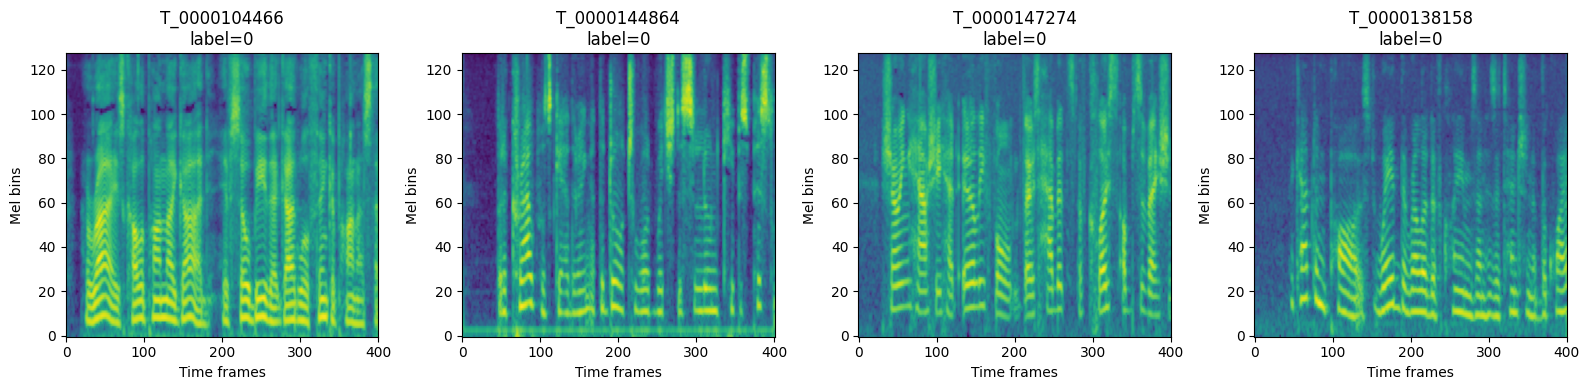

In [ ]:
def show_spectrogram_examples(dataset: SpoofDataset, num_examples: int = 4):
    fig, axes = plt.subplots(1, num_examples, figsize=(4 * num_examples, 4))
    if num_examples == 1:
        axes = [axes]
    for i in range(num_examples):
        features, label, file_id = dataset[i]
        ax = axes[i]
        ax.imshow(features.squeeze(0).numpy(), aspect="auto", origin="lower")
        ax.set_title(f"{file_id}\nlabel={int(label)}")
        ax.set_xlabel("Time frames")
        ax.set_ylabel("Mel bins")
    plt.tight_layout()
    plt.show()

show_spectrogram_examples(train_dataset, num_examples=4)

Model Architecture

In [27]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class SpoofCNN(nn.Module):
    def __init__(self, base_channels: int = 32, dropout: float = 0.3, num_classes: int = 2):
        super().__init__()
        c1, c2, c3 = base_channels, base_channels * 2, base_channels * 4

        self.features = nn.Sequential(
            ConvBlock(1,  c1, dropout=dropout / 2),
            ConvBlock(c1, c2, dropout=dropout / 2),
            ConvBlock(c2, c3, dropout=dropout),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, c2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(c2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.pool(self.features(x)))


model = SpoofCNN(base_channels=32, dropout=0.3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

SpoofCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.15, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1

Training and Evaluation

In [9]:
SAVE_DIR = PROJECT_ROOT / "saved_models"
SAVE_DIR.mkdir(exist_ok=True)

In [28]:
def get_class_weights(labels) -> torch.Tensor:
    counts      = Counter(labels)
    total       = sum(counts.values())
    num_classes = len(counts)
    weights     = [total / (num_classes * counts[cls]) for cls in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float32)


def compute_eer(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fnr[idx] + fpr[idx]) / 2.0), float(thresholds[idx])


def compute_binary_metrics(y_true, y_prob, threshold: float = 0.5) -> dict:
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = float("nan")
    try:
        eer, eer_thr = compute_eer(y_true, y_prob)
    except Exception:
        eer, eer_thr = float("nan"), float("nan")
    return {
        "accuracy":      float(acc),
        "precision":     float(prec),
        "recall":        float(rec),
        "f1":            float(f1),
        "roc_auc":       float(auc),
        "eer":           float(eer),
        "eer_threshold": float(eer_thr),
        "threshold":     float(threshold),
    }

def compute_spoof_metrics(y_true, y_prob, threshold=0.5):
    """
    Assumes:
      bonafide = 0
      spoof    = 1
    y_prob is probability of class 1 (spoof).
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {}

    metrics["threshold"] = float(threshold)
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)

    # Class-specific metrics
    metrics["spoof_precision"] = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    metrics["spoof_recall"] = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    metrics["spoof_f1"] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    metrics["bonafide_precision"] = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    metrics["bonafide_recall"] = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    metrics["bonafide_f1"] = f1_score(y_true, y_pred, pos_label=0, zero_division=0)

    # Combined F1 metrics requested
    metrics["macro_f1"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["weighted_f1"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    # Ranking metrics
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics["roc_auc"] = np.nan

    try:
        metrics["pr_auc_spoof"] = average_precision_score(y_true, y_prob)
    except Exception:
        metrics["pr_auc_spoof"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics["tn"] = int(tn)
    metrics["fp"] = int(fp)
    metrics["fn"] = int(fn)
    metrics["tp"] = int(tp)

    metrics["false_positive_rate"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["false_negative_rate"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics, y_pred

def find_best_threshold(y_true, y_prob) -> tuple:
    best_threshold, best_score, best_metrics = 0.5, -1.0, None
    for thr in np.linspace(0.05, 0.95, 91):
        m = compute_binary_metrics(y_true, y_prob, threshold=float(thr))
        if m["f1"] > best_score:
            best_score, best_threshold, best_metrics = m["f1"], float(thr), m
    return best_threshold, best_metrics


def evaluate_model(model, loader, criterion, threshold: float = 0.5):
    model.eval()
    total_loss, all_probs, all_labels, all_file_ids = 0.0, [], [], []
    with torch.no_grad():
        for x, y, file_ids in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits     = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            probs       = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
            all_file_ids.extend(list(file_ids))
    avg_loss = total_loss / len(loader.dataset)
    metrics  = compute_binary_metrics(all_labels, all_probs, threshold=threshold)
    metrics["loss"] = float(avg_loss)
    return metrics, np.array(all_probs), np.array(all_labels), np.array(all_file_ids)


def train_one_epoch(model, loader, criterion, optimizer) -> float:
    model.train()
    total_loss = 0.0
    for x, y, _ in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        # Gradient clipping for training stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


def fit_model(
    model,
    train_loader,
    val_loader,
    epochs: int,
    lr: float,
    weight_decay: float,
    delta: float,
    class_weights=None,
    trial=None
):
    criterion = (
        nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
        if class_weights is not None
        else nn.CrossEntropyLoss()
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

    history = {k: [] for k in [
        "train_loss", "val_loss", "val_accuracy",
        "val_f1", "val_roc_auc", "val_best_threshold",
    ]}
    best_state, best_val_f1 = None, -1.0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)

        val_metrics_05, val_probs, val_labels, _ = evaluate_model(
            model, val_loader, criterion, threshold=0.5
        )
        best_threshold, tuned_val_metrics = find_best_threshold(val_labels, val_probs)
        tuned_val_metrics["loss"] = val_metrics_05["loss"]

        scheduler.step(tuned_val_metrics["f1"])

        for key, val in [
            ("train_loss",         train_loss),
            ("val_loss",           tuned_val_metrics["loss"]),
            ("val_accuracy",       tuned_val_metrics["accuracy"]),
            ("val_f1",             tuned_val_metrics["f1"]),
            ("val_roc_auc",        tuned_val_metrics["roc_auc"]),
            ("val_best_threshold", best_threshold),
        ]:
            history[key].append(val)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={tuned_val_metrics['loss']:.4f} | "
            f"val_acc={tuned_val_metrics['accuracy']:.4f} | "
            f"val_f1={tuned_val_metrics['f1']:.4f} | "
            f"val_auc={tuned_val_metrics['roc_auc']:.4f} | "
            f"best_thr={best_threshold:.2f}"
        )

        # if model improved
        if tuned_val_metrics["f1"] > best_val_f1:
            best_val_f1 = tuned_val_metrics["f1"]
            best_state  = {
                "model_state_dict": {
                    k: v.cpu().clone() for k, v in model.state_dict().items()
                },
                "best_val_metrics": tuned_val_metrics,
                "best_threshold":   float(best_threshold),
                "epoch":            epoch,
            }
            # save model
            save_dir = SAVE_DIR / f"lr{lr}_decay{weight_decay}"
            filename = f"model_lr{lr}_decay{weight_decay}_epoch{epoch:02d}.pt"
            save_model(model, save_dir, filename)

        # # Check for delta value and early stop criterion
        # if len(history["val_f1"]) >= 2:
        #   difference = abs(history["val_f1"][-1] - history["val_f1"][-2])
        #   if(difference < delta and history["val_f1"][-1] > 0.75): #I changed this part for early stopping
        #       message = "Stopping early - F1 score evolution was less than delta on"
        #       message += f"epoch {epoch:02d}."
        #       print(message)
        #       break

        # early stopping
        patience = 5 # stop if no improvement for 5 epochs
        if len(history["val_f1"]) >= patience:
          epochs_without_improvement = len(history["val_f1"]) - history["val_f1"].index(best_val_f1) - 1
          if epochs_without_improvement >= patience:
              print(f"Early stopping triggered after {patience} epochs without improvement.")
              break


        # Optuna pruning: kill unpromising trials early
        if trial is not None:
          trial.report(tuned_val_metrics["f1"], epoch)
          if trial.should_prune():
              print(f"Trial pruned at epoch {epoch}")
              raise optuna.TrialPruned()

    return history, best_state

def save_model(model, dir, filename):

  dir.mkdir(parents=True, exist_ok=True)

  path = os.path.join(dir, filename)

  print(f"Model improved, saving best model to {path}...")
  torch.save(model.state_dict(), path)

class_weights = get_class_weights(train_df["label"])

print("Training functions defined.")

Training functions defined.


In [ ]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

global_best = {"f1": -1.0, "state": None, "params": None}

def objective(trial):
  # hyperparameter search space
  lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
  weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
  dropout = trial.suggest_float("dropout", 0.1, 0.5)

  model = SpoofCNN(base_channels=32, dropout=dropout).to(DEVICE)

  history, best_state = fit_model(
      model,
      train_loader,
      val_loader,
      epochs=35,
      lr=lr,
      weight_decay=weight_decay,
      delta=1e-4,
      class_weights=class_weights,
      trial=trial
  )

  trial_best_f1 = best_state["best_val_metrics"]["f1"] if best_state else -1.0

  # Save globally best model across all trials
  if trial_best_f1 > global_best["f1"]:
      global_best["f1"]     = trial_best_f1
      global_best["state"]  = best_state
      global_best["params"] = trial.params

      save_dir = SAVE_DIR / "global_best"
      save_dir.mkdir(parents=True, exist_ok=True)
      torch.save(
          {**best_state, "trial_params": trial.params},
          save_dir / "global_best_model.pt",
      )
      print(f"  *** New global best: F1={trial_best_f1:.4f} | params={trial.params}")

  return trial_best_f1

def run_optuna_search(n_trials: int = 30, n_jobs: int = 1):
  sampler = TPESampler(seed=42)
  pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=5)

  study = optuna.create_study(
      direction="maximize",
      sampler=sampler,
      pruner=pruner
  )

  study.optimize(objective, n_trials=n_trials, n_jobs=n_jobs)

  print("\n===== Optuna Search Complete =====")
  print(f"Best trial F1 : {study.best_value:.4f}")
  print(f"Best params   : {study.best_params}")
  print(f"Global best F1: {global_best['f1']:.4f}")

  return study

print("Optuna hyperparameter tuning functions defined.")


Optuna hyperparameter tuning functions defined.


In [ ]:
# run training/hyperparameter tuning
study = run_optuna_search(n_trials=3, n_jobs=1)

[I 2026-04-15 06:49:05,774] A new study created in memory with name: no-name-5fca4fad-8105-4410-8b98-b0d1324ab59b


  0%|          | 0/619 [00:00<?, ?it/s]

Epoch 01/35 | train_loss=0.1961 | val_loss=1.6874 | val_acc=0.5337 | val_f1=0.1459 | val_auc=0.7869 | best_thr=0.95
Model improved, saving best model to /content/drive/MyDrive/DL Project/saved_models/lr0.0001329291894316216_decay0.006351221010640704/model_lr0.0001329291894316216_decay0.006351221010640704_epoch01.pt...


  0%|          | 0/619 [00:00<?, ?it/s]

Epoch 02/35 | train_loss=0.0975 | val_loss=0.8243 | val_acc=0.9672 | val_f1=0.6675 | val_auc=0.8870 | best_thr=0.14
Model improved, saving best model to /content/drive/MyDrive/DL Project/saved_models/lr0.0001329291894316216_decay0.006351221010640704/model_lr0.0001329291894316216_decay0.006351221010640704_epoch02.pt...


...

  0%|          | 0/619 [00:00<?, ?it/s]

Epoch 07/35 | train_loss=0.1270 | val_loss=0.8676 | val_acc=0.9389 | val_f1=0.5008 | val_auc=0.7994 | best_thr=0.95


  0%|          | 0/619 [00:00<?, ?it/s]

[I 2026-04-15 18:59:46,119] Trial 2 finished with value: 0.6062389640965273 and parameters: {'lr': 1.493656855461762e-05, 'weight_decay': 0.0029154431891537554, 'dropout': 0.34044600469728353}. Best is trial 1 with value: 0.6695589298626174.


Epoch 08/35 | train_loss=0.1240 | val_loss=1.5108 | val_acc=0.6663 | val_f1=0.1947 | val_auc=0.8189 | best_thr=0.95
Early stopping triggered after 5 epochs without improvement.

===== Optuna Search Complete =====
Best trial F1 : 0.6696
Best params   : {'lr': 0.0006251373574521745, 'weight_decay': 4.2079886696066345e-06, 'dropout': 0.16239780813448107}
Global best F1: 0.6696


In [5]:
def load_best_model(checkpoint_path, model_class, device=DEVICE):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    trial_params = checkpoint.get("trial_params", {})
    model_config = checkpoint.get("model_config", {})

    base_channels = model_config.get("base_channels", 32)
    dropout = model_config.get("dropout", trial_params.get("dropout", 0.3))

    model = model_class(base_channels=base_channels, dropout=dropout).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"Loaded model from epoch {checkpoint.get('epoch', 'N/A')}")
    print(f"Best val metrics : {checkpoint.get('best_val_metrics', {})}")
    print(f"Best threshold   : {checkpoint.get('best_threshold', 0.5)}")
    print(f"Trial params     : {trial_params}")

    return model, checkpoint


def test_best_model(
    checkpoint_path,
    model_class,
    test_loader,
    class_weights=None,
    device=DEVICE,
    save_predictions_path=None,
):
    model, checkpoint = load_best_model(checkpoint_path, model_class, device=device)
    best_threshold = checkpoint.get("best_threshold", 0.5)

    criterion = (
        nn.CrossEntropyLoss(weight=class_weights.to(device))
        if class_weights is not None
        else nn.CrossEntropyLoss()
    )

    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0
    total_n = 0

    with torch.no_grad():
        for xb, yb, _ in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            probs = torch.softmax(logits, dim=1)[:, 1]  # probability of spoof

            batch_size = yb.size(0)
            total_loss += loss.item() * batch_size
            total_n += batch_size

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / total_n if total_n > 0 else np.nan
    metrics, y_pred = compute_spoof_metrics(all_labels, all_probs, threshold=best_threshold)
    metrics["loss"] = avg_loss

    print("\n===== Test Set Results =====")
    print(f"Threshold            : {metrics['threshold']:.2f}")
    print(f"Loss                 : {metrics['loss']:.4f}")
    print(f"Accuracy             : {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy    : {metrics['balanced_accuracy']:.4f}")
    print(f"Spoof Precision      : {metrics['spoof_precision']:.4f}")
    print(f"Spoof Recall         : {metrics['spoof_recall']:.4f}")
    print(f"Spoof F1             : {metrics['spoof_f1']:.4f}")
    print(f"Bonafide Precision   : {metrics['bonafide_precision']:.4f}")
    print(f"Bonafide Recall      : {metrics['bonafide_recall']:.4f}")
    print(f"Bonafide F1          : {metrics['bonafide_f1']:.4f}")
    print(f"Macro F1             : {metrics['macro_f1']:.4f}")
    print(f"Weighted F1          : {metrics['weighted_f1']:.4f}")
    print(f"ROC-AUC              : {metrics['roc_auc']:.4f}")
    print(f"PR-AUC (Spoof)       : {metrics['pr_auc_spoof']:.4f}")

    print("\nConfusion Matrix [rows=true, cols=pred]:")
    cm = np.array([[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]])
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            np.asarray(all_labels).astype(int),
            np.asarray(y_pred).astype(int),
            target_names=["bonafide", "spoof"],
            digits=4,
            zero_division=0,
        )
    )

    pred_df = pd.DataFrame({
        "y_true": np.asarray(all_labels).astype(int),
        "y_prob_spoof": np.asarray(all_probs).astype(float),
        "y_pred": np.asarray(y_pred).astype(int),
    })

    if save_predictions_path is not None:
        pred_df.to_csv(save_predictions_path, index=False)
        print(f"Saved test predictions to: {save_predictions_path}")

    return metrics, np.asarray(all_probs), np.asarray(all_labels), np.asarray(y_pred), pred_df

In [2]:
def plot_test_curves(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (Spoof)")
    plt.show()


def plot_confusion_matrix_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["bonafide", "spoof"])
    plt.yticks([0, 1], ["bonafide", "spoof"])
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

Loaded model from epoch 6
Best val metrics : {'accuracy': 0.9714214245513101, 'precision': 0.7941680960548885, 'recall': 0.57875, 'f1': 0.6695589298626174, 'roc_auc': 0.8810850585873214, 'eer': 0.17343941313935882, 'eer_threshold': 2.5159712095046416e-05, 'threshold': 0.07, 'loss': 2.0777896245917}
Best threshold   : 0.07
Trial params     : {'lr': 0.0006251373574521745, 'weight_decay': 4.2079886696066345e-06, 'dropout': 0.16239780813448107}

===== Test Set Results =====
Threshold            : 0.07
Loss                 : 2.2285
Accuracy             : 0.9684
Balanced Accuracy    : 0.7676
Spoof Precision      : 0.7552
Spoof Recall         : 0.5444
Spoof F1             : 0.6327
Bonafide Precision   : 0.9764
Bonafide Recall      : 0.9907
Bonafide F1          : 0.9835
Macro F1             : 0.8081
Weighted F1          : 0.9660
ROC-AUC              : 0.8683
PR-AUC (Spoof)       : 0.6681

Confusion Matrix [rows=true, cols=pred]:
[[15051   141]
 [  364   435]]

Classification Report:
          

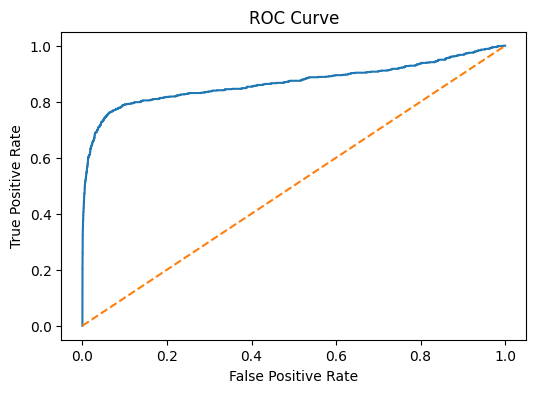

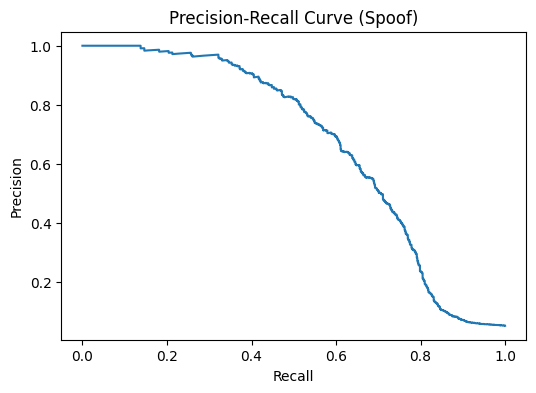

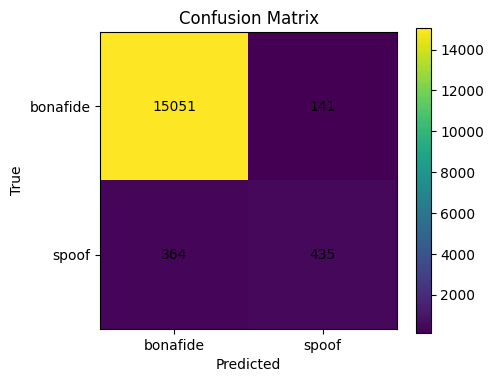

In [29]:
# run testing
test_metrics, test_probs, test_labels, test_preds, test_pred_df = test_best_model(
    checkpoint_path=SAVE_DIR / "global_best" / "global_best_model.pt",
    model_class=SpoofCNN,
    test_loader=test_loader,
    class_weights=class_weights,
    save_predictions_path=OUTPUT_DIR / "test_predictions_with_metrics.csv",
)

plot_test_curves(test_labels, test_probs)
plot_confusion_matrix_from_preds(test_labels, test_preds)